## Calculating the critical threshold

In [1]:
import aliases # important this goes first to configure PATH

In [13]:
import os
import pickle
import math

import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import numpy as np

from everest.window import Canvas, DataChannel as Channel

In [3]:
with open(
        os.path.join(
            aliases.storagedir, 'livestation', 'alphacrit_f_fine.pkl'
            ), mode='rb'
        ) as file:
    olddatas = pickle.load(file)

with open(
        os.path.join(
            aliases.storagedir, 'livestation', 'alphacrit_aspect_f.pkl'
            ), mode='rb'
        ) as file:
    alldatas = pickle.load(file)
newdatas = alldatas[1.0]

datas = {**olddatas, **newdatas}

In [27]:
datas

{3.249009585424942: [1278.8907074292943,
  1370.6811217069842,
  1574.4991497303035,
  1472.590135718644,
  1421.6356287128142,
  1396.158375209899,
  1408.8970019613566,
  1415.2663153370854,
  1412.081658649221,
  1413.6739869931532,
  1412.8778228211872,
  1413.2759049071701,
  1413.0768638641787,
  1412.977343342683,
  1413.027103603431,
  1413.0519837338047,
  1413.0644237989918],
 1.0: [800.0,
  857.4187700290345,
  828.7093850145172,
  843.0640775217759,
  850.2414237754051,
  853.8300969022198,
  852.0357603388125,
  851.1385920571088,
  850.690007916257,
  850.9142999866829,
  850.8021539514699,
  850.7460809338634,
  850.7180444250602,
  850.7320626794617,
  850.7390718066625],
 2.6390158215457884: [980.6829229183484,
  1051.0699319464109,
  1207.3623018136877,
  1129.2161168800494,
  1090.1430244132303,
  1070.6064781798204,
  1060.8382050631158,
  1065.722341621468,
  1063.2802733422918,
  1064.5013074818798,
  1065.111824551674,
  1064.806566016777,
  1064.6539367493283,
 

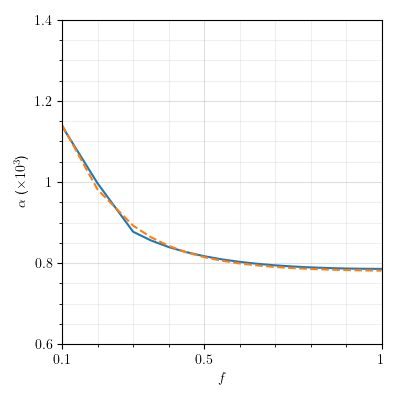

In [4]:
series = pd.Series({key: datas[key][-1] for key in sorted(datas)})

canvas = Canvas(size = (4, 4), shape = (1, 1))

ax = canvas.make_ax()
ax.line(
    xchan := Channel(
        series.index, label=r"$f$",
        capped=(True, True), log=False
        ),
    Channel(series.values, label=r"$\alpha$"),
    )

def func(x, /, a, b, c):
    return a * b**(x - c) + 8*math.pi**4
(*params,), error = curve_fit(func, series.index, series.values)
params = dict(zip('abcd', (map(float, params))))
model = func(series.index, **params)

ax.line(
    xchan,
    Channel(model),
    linestyle='--',
    )

canvas

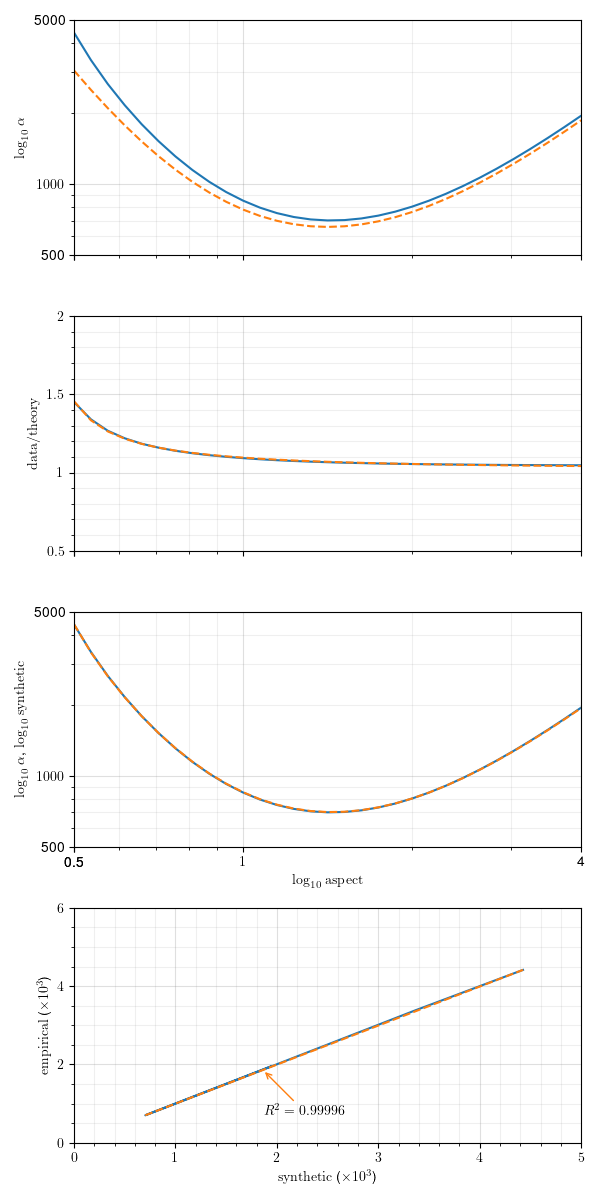

{'a': 0.0953389728853824,
 'b': 2.5102269596407503,
 'c': -0.4103586573941481,
 'd': 1.0305804697105057}

In [26]:
with open(
        os.path.join(
            aliases.storagedir, 'livestation', 'alphacrit_aspect_fine.pkl'
            ), mode='rb'
        ) as file:
    datas = pickle.load(file)

crit_func = lambda A: math.pi**4 * (1 + A**2)**3 / A**4
series = pd.Series({key: datas[key][-1] for key in sorted(datas)})
independent = series.index
empirical = series.values
theory = tuple(map(crit_func, series.index))
discrepancy = empirical / theory

canvas = Canvas(size = (6, 12), shape = (4, 1))

ax1 = canvas.ax((0, 0))
ax1.line(
    xchan := Channel(
        independent, label=r"$\mathrm{aspect}$",
        log=True, capped=(True, True),
        ),
    ychan := Channel(empirical, label=r"$\alpha$", log=True),
    )
ax1.line(
    xchan, Channel(theory, log=True),
    linestyle='--',
    )

ax1.props.edges.x.label.visible = False
ax1.props.edges.x.ticks.major.labels = ()
# ax1.props.edges.x.swap()
# ax1.props.edges.x.ticks.major.labels[:] = []

def func(x, /, a, b, c, d):
    return a / (b*(x + c)) + d
(*params,), error = curve_fit(func, series.index, discrepancy)
params = dict(zip('abcd', (map(float, params))))

correction = func(series.index, **params)

ax2 = canvas.ax((1, 0))
ax2.line(
    xchan,
    Channel(discrepancy, label=r'$\mathrm{data} / \mathrm{theory}$'),
    )
ax2.line(
    xchan,
    Channel(correction),
    linestyle='--',
    )

ax2.props.edges.x.label.visible = False
ax2.props.edges.x.ticks.major.labels = ()

synthetic = theory * correction

ax3 = canvas.ax((2, 0))
ax3.line(
    xchan,
    ychan,
    )
ax3.line(
    xchan,
    Channel(synthetic, label=r"$\mathrm{synthetic}$", log=True),
    linestyle='--',
    )

ax4 = canvas.ax((3, 0))
ax4.line(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(empirical, label=r"$\mathrm{empirical}$"),
    )
linscore = r2_score(synthetic, empirical)
ax4.line(
    Channel(np.linspace(min(synthetic), max(synthetic), 100)),
    Channel(np.linspace(min(empirical), max(empirical), 100)),
    linestyle = '--',
    )
ax4.annotate(
    (max(synthetic) - min(synthetic)) / 2,
    (max(empirical) - min(empirical)) / 2,
    label = f"${'R^2 =' + str(round(linscore, 5))}$",
    points = (30, -30),
    arrowprops = dict(arrowstyle = "->", color = '#ff7f0e'),
    )

display(canvas)
display(params)

In [19]:
round(len(synthetic) / 2)

16

In [21]:
len(synthetic)

31

In [22]:
synthetic

Index([ 4426.851603857657,  3358.125462911688, 2657.3659702661175,
       2162.3221566107345, 1798.1006888829427, 1523.5439656205288,
       1313.4342859704002, 1151.2016949715385, 1025.4484381710977,
        928.0942159211241,  853.2980892984899,  796.7902385911474,
        755.4375348130362,  726.9511656568978,  709.6850729988261,
        702.4949006476598,  704.6386786748004,  715.7071736522132,
        735.5759217705072,  764.3735598317129,  802.4627812888251,
         850.431410109868,  909.0919031861374,  979.4881834986556,
       1062.9091478383182, 1160.9085344804207, 1275.3311114597323,
       1408.3453783213124,  1562.483180180272,  1740.686825063989,
       1946.3644834833692],
      dtype='float64')